# iDLG Attack: PSNR & SSIM Analysis
Loads `idlg_results_export.json` and plots PSNR/SSIM convergence curves and per-alpha summary for the iDLG attack on LeNet.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
%matplotlib inline

with open('idlg_results_export.json') as f:
    idlg_json = json.load(f)

ALPHAS     = [1, 0.99, 0.98, 0.97, 0.96, 0.95, 0.94, 0.93, 0.92, 0.91, 0.90, 0.05, 0.0]
SEEDS      = [10, 20, 30]
N_IMAGES   = 30
N_RESTARTS = 5
FS         = 10

HIGHLIGHT = [
    ('prune', 1.00, 'No Defense (α=1)',    'steelblue',      '-'),
    ('prune', 0.95, 'PLGP (α=0.95)',        'darkcyan',       '-'),
    ('prune', 0.90, 'PLGP (α=0.90)',        'mediumseagreen', '-'),
    ('prune', 0.05, 'PLGP best (α=0.05)',   'seagreen',       '-.'),
    ('prune', 0.00, 'Strict LGP (α=0)',     'darkorange',     ':'),
    ('clip',  1.00, 'Gradient Clipping',         'tomato',         '--'),
]


def load_curves(method, alpha):
    psnr_final = np.full((len(SEEDS), N_IMAGES), np.nan)
    ssim_final = np.full((len(SEEDS), N_IMAGES), np.nan)
    psnr_curves, ssim_curves = [], []

    for si, seed in enumerate(SEEDS):
        for img in range(N_IMAGES):
            best_p, best_s = np.nan, np.nan
            best_pc, best_sc = None, None
            for r in range(N_RESTARTS):
                key   = f'{method}_{alpha:.2f}_{seed}_{img}_{r}'
                entry = idlg_json.get(key)
                if not entry or not entry.get('psnr'):
                    continue
                p = entry['psnr'][-1]
                s = entry['ssim'][-1] if entry.get('ssim') else np.nan
                if np.isnan(best_p) or p > best_p:
                    best_p, best_s = p, s
                    best_pc = np.array(entry['psnr'])
                    best_sc = np.array(entry['ssim']) if entry.get('ssim') else None
            psnr_final[si, img] = best_p
            ssim_final[si, img] = best_s
            if best_pc is not None:
                psnr_curves.append(best_pc)
            if best_sc is not None:
                ssim_curves.append(best_sc)

    def _mean_curve(curves):
        if not curves:
            return None
        max_len = max(len(c) for c in curves)
        mat = np.full((len(curves), max_len), np.nan)
        for i, c in enumerate(curves):
            mat[i, :len(c)] = c
            mat[i, len(c):] = c[-1]
        return np.nanmean(mat, axis=0)

    return psnr_final, ssim_final, _mean_curve(psnr_curves), _mean_curve(ssim_curves)

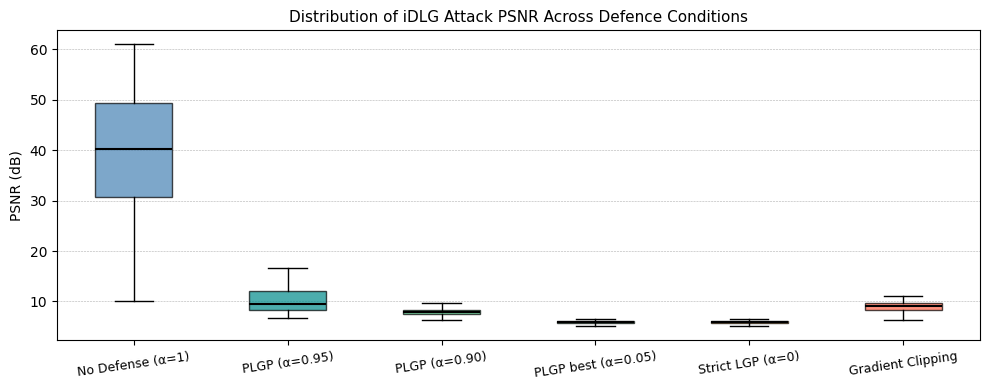

In [2]:
# Aggregate PSNR distributions
results = {}

for method, alpha, label, color, linestyle in HIGHLIGHT:

    psnr_final, ssim_final, _, _ = load_curves(method, alpha)

    psnr_vals = psnr_final.flatten()
    psnr_vals = psnr_vals[~np.isnan(psnr_vals)]

    results[(method, alpha)] = {
        'psnr': psnr_vals,
        'n': len(psnr_vals)
    }


# Build boxplot inputs
data, labels, colors = [], [], []

for method, alpha, label, color, linestyle in HIGHLIGHT:

    r = results[(method, alpha)]

    if r['n'] > 0:
        data.append(r['psnr'])
        labels.append(label.replace('ÃŽÂ±', 'Î±'))
        colors.append(color)


# Plot
fig, ax = plt.subplots(figsize=(10, 4))

bp = ax.boxplot(
    data,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color='black', linewidth=1.5)
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels, fontsize=FS-1, rotation=8)

ax.set_ylabel('PSNR (dB)', fontsize=FS)

ax.set_title(
    'Distribution of iDLG Attack PSNR Across Defence Conditions',
    fontsize=FS+1
)

ax.grid(True, axis='y', linestyle='--', linewidth=0.4)

ax.tick_params(axis='y', labelsize=FS)

plt.tight_layout()
plt.show()

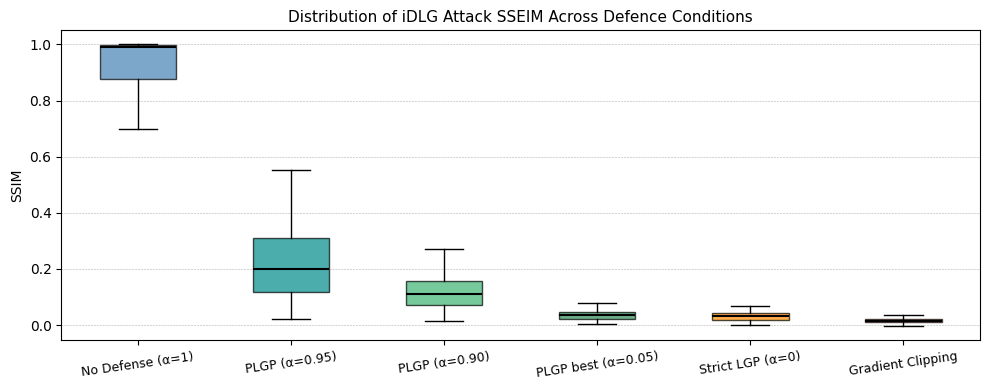

In [3]:
# Aggregate PSNR distributions
results = {}

for method, alpha, label, color, linestyle in HIGHLIGHT:

    psnr_final, ssim_final, _, _ = load_curves(method, alpha)

    ssim_vals = ssim_final.flatten()
    ssim_vals = ssim_vals[~np.isnan(ssim_vals)]

    results[(method, alpha)] = {
        'ssim': ssim_vals,
        'n': len(ssim_vals)
    }


# Build boxplot inputs
data, labels, colors = [], [], []

for method, alpha, label, color, linestyle in HIGHLIGHT:

    r = results[(method, alpha)]

    if r['n'] > 0:
        data.append(r['ssim'])
        labels.append(label.replace('ÃŽÂ±', 'Î±'))
        colors.append(color)


# Plot
fig, ax = plt.subplots(figsize=(10, 4))

bp = ax.boxplot(
    data,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color='black', linewidth=1.5)
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels, fontsize=FS-1, rotation=8)

ax.set_ylabel('SSIM', fontsize=FS)

ax.set_title(
    'Distribution of iDLG Attack SSEIM Across Defence Conditions',
    fontsize=FS+1
)

ax.grid(True, axis='y', linestyle='--', linewidth=0.4)

ax.tick_params(axis='y', labelsize=FS)

plt.tight_layout()
plt.show()

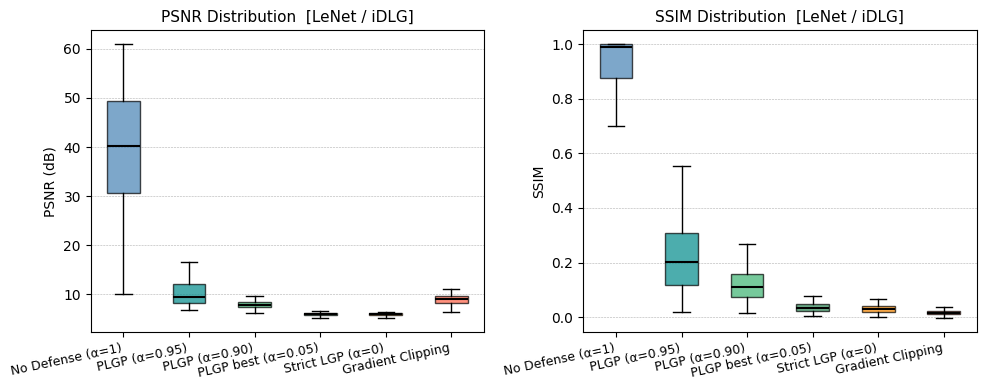

Saved figures/idlg_lenet_psnr_ssim_boxplot.pdf


In [4]:
import os

data_p, data_s, labels, colors = [], [], [], []
for method, alpha, label, color, ls in HIGHLIGHT:
    psnr_final, ssim_final, _, _ = load_curves(method, alpha)
    psnr_vals = psnr_final.flatten()
    ssim_vals = ssim_final.flatten()
    psnr_vals = psnr_vals[~np.isnan(psnr_vals)]
    ssim_vals = ssim_vals[~np.isnan(ssim_vals)]
    if len(psnr_vals) > 0:
        data_p.append(psnr_vals)
        data_s.append(ssim_vals)
        labels.append(label)
        colors.append(color)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

for ax, data, ylabel, title in [
    (ax1, data_p, 'PSNR (dB)', 'PSNR Distribution  [LeNet / iDLG]'),
    (ax2, data_s, 'SSIM',      'SSIM Distribution  [LeNet / iDLG]'),
]:
    bp = ax.boxplot(data, patch_artist=True, showfliers=False,
                    medianprops=dict(color='black', linewidth=1.5))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, fontsize=FS - 1, rotation=12, ha='right')
    ax.set_ylabel(ylabel, fontsize=FS)
    ax.set_title(title, fontsize=FS + 1)
    ax.grid(True, axis='y', linestyle='--', linewidth=0.4)
    ax.tick_params(axis='y', labelsize=FS)

plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/idlg_lenet_psnr_ssim_boxplot.pdf", dpi=300, bbox_inches="tight")
plt.show()
print("Saved figures/idlg_lenet_psnr_ssim_boxplot.pdf")

## PSNR & SSIM Convergence Curves

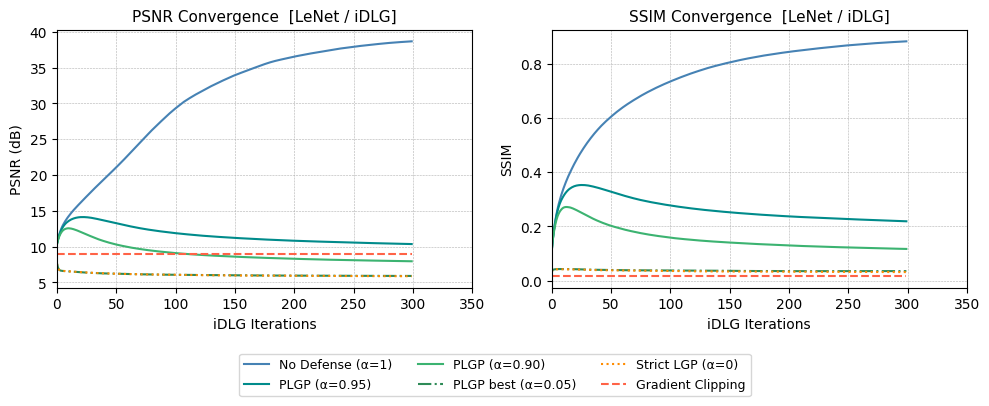

In [5]:
fig = plt.figure(figsize=(10, 4))
gs  = GridSpec(1, 2, figure=fig)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
lines, labels = [], []

for method, alpha, label, color, ls in HIGHLIGHT:
    _, _, pc, sc = load_curves(method, alpha)
    if pc is None:
        continue
    iters = np.arange(len(pc))
    line, = ax1.plot(iters, pc, label=label, color=color, linestyle=ls, linewidth=1.5)
    lines.append(line)
    labels.append(label)
    if sc is not None:
        ax2.plot(np.arange(len(sc)), sc, color=color, linestyle=ls, linewidth=1.5)

ax1.set_xlim(0, 350)
ax1.set_xlabel('iDLG Iterations', fontsize=FS)
ax1.set_ylabel('PSNR (dB)', fontsize=FS)
ax1.set_title('PSNR Convergence  [LeNet / iDLG]', fontsize=FS+1)
ax1.grid(True, linestyle='--', linewidth=0.4)
ax1.tick_params(labelsize=FS)

ax2.set_xlim(0, 350)
ax2.set_xlabel('iDLG Iterations', fontsize=FS)
ax2.set_ylabel('SSIM', fontsize=FS)
ax2.set_title('SSIM Convergence  [LeNet / iDLG]', fontsize=FS+1)
ax2.grid(True, linestyle='--', linewidth=0.4)
ax2.tick_params(labelsize=FS)

if lines:
    fig.legend(handles=lines, labels=labels,
               loc='lower center', ncol=min(len(labels), 3),
               fontsize=FS-1, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.show()

## Mean PSNR per Alpha (all seeds Ãƒâ€” images)

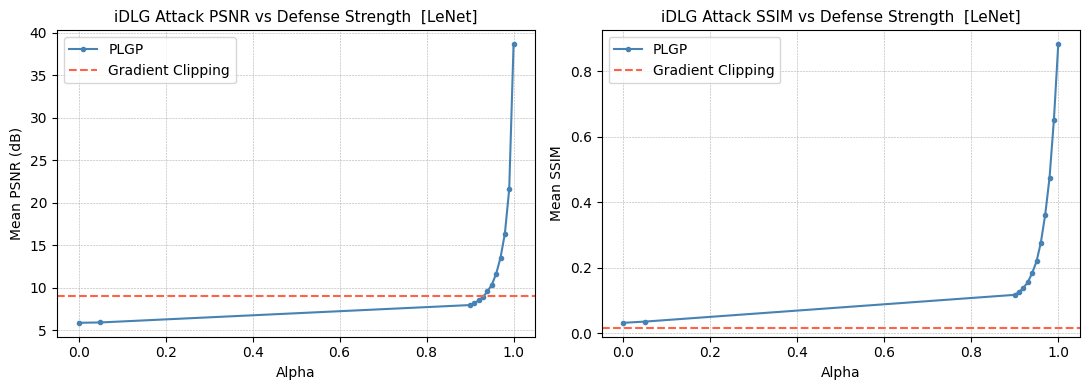

In [6]:
psnr_means, ssim_means = [], []
for alpha in ALPHAS:
    pf, sf, _, _ = load_curves('prune', alpha)
    psnr_means.append(float(np.nanmean(pf)))
    ssim_means.append(float(np.nanmean(sf)))

pf_c, sf_c, _, _ = load_curves('clip', 1)
pm_c = float(np.nanmean(pf_c))
sm_c = float(np.nanmean(sf_c))

alphas_arr = np.array(ALPHAS)
pm_arr = np.array(psnr_means)
sm_arr = np.array(ssim_means)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
mask = ~np.isnan(pm_arr)
ax.plot(alphas_arr[mask], pm_arr[mask], '.-', color='steelblue', linewidth=1.5, label='PLGP')
if not np.isnan(pm_c):
    ax.axhline(pm_c, color='tomato', linestyle='--', label='Gradient Clipping')
ax.set_xlabel('Alpha', fontsize=FS)
ax.set_ylabel('Mean PSNR (dB)', fontsize=FS)
ax.set_title('iDLG Attack PSNR vs Defense Strength  [LeNet]', fontsize=FS+1)
ax.legend(fontsize=FS)
ax.grid(True, linestyle='--', linewidth=0.4)
ax.tick_params(labelsize=FS)

ax = axes[1]
mask = ~np.isnan(sm_arr)
ax.plot(alphas_arr[mask], sm_arr[mask], '.-', color='steelblue', linewidth=1.5, label='PLGP')
if not np.isnan(sm_c):
    ax.axhline(sm_c, color='tomato', linestyle='--', label='Gradient Clipping')
ax.set_xlabel('Alpha', fontsize=FS)
ax.set_ylabel('Mean SSIM', fontsize=FS)
ax.set_title('iDLG Attack SSIM vs Defense Strength  [LeNet]', fontsize=FS+1)
ax.legend(fontsize=FS)
ax.grid(True, linestyle='--', linewidth=0.4)
ax.tick_params(labelsize=FS)

plt.tight_layout()
plt.show()

## Reconstruction Grid: iDLG vs InvGrad (LeNet, image 21, seed=10)
Comparison grid for both attacks

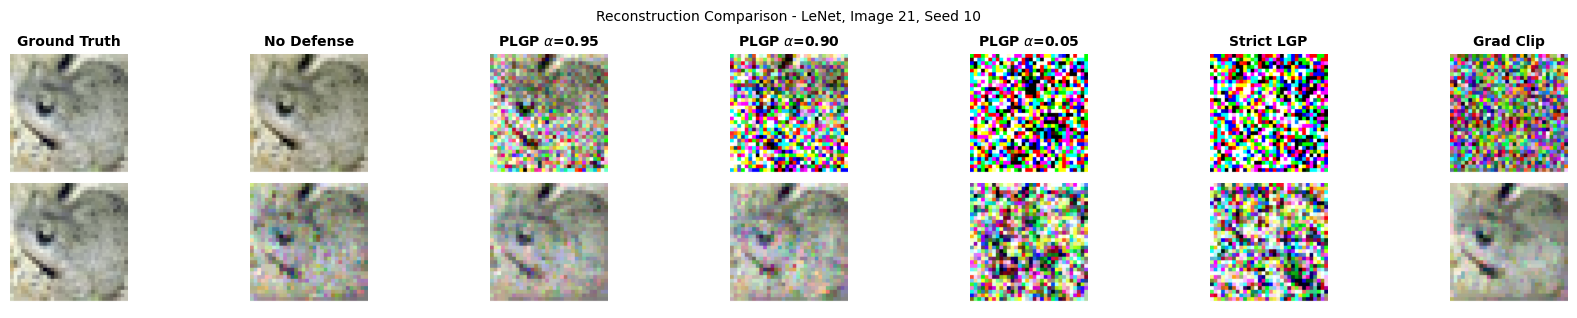

Saved figures/recon_grid_lenet_img21.pdf


In [8]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

IMG_IDX      = 21
SEED         = 10
IDLG_DIR     = "results/idlg_experiments/figs"
INVG_DIR     = "."
IMG_START_ROW = 209   # row (within top-half panel) where the actual image begins

CONDITIONS = [
    ("prune", 1.00, "No Defense"),
    ("prune", 0.95, r"PLGP $\alpha$=0.95"),
    ("prune", 0.90, r"PLGP $\alpha$=0.90"),
    ("prune", 0.05, r"PLGP $\alpha$=0.05"),
    ("prune", 0.00, "Strict LGP"),
    ("clip",  1.00, "Grad Clip"),
]

def extract_image(path, side="left"):
    """Crop just the 629×629 image content, skipping all text labels."""
    img = Image.open(path).convert("RGB")
    w, h = img.size
    top = img.crop((0, 0, w, h // 2))
    tw, th = top.size
    panel = top.crop((0, 0, tw // 2, th)) if side == "left" else top.crop((tw // 2, 0, tw, th))
    arr = np.array(panel)
    nw = ~np.all(arr > 235, axis=2)
    cols = np.where(nw[IMG_START_ROW:, :].any(axis=0))[0]
    c0, c1 = int(cols[0]), int(cols[-1]) + 1
    return panel.crop((c0, IMG_START_ROW, c1, arr.shape[0]))

def best_idlg(method, alpha):
    files = sorted(glob.glob(
        f"{IDLG_DIR}/img_{IMG_IDX}_seed_{SEED}_alpha_{alpha:.2f}_method_{method}_*.png"))
    if not files: return None
    return next((f for f in files if f.endswith("_0.png")), files[0])

def invgrad_path(method, alpha):
    p = (f"{INVG_DIR}/img_{IMG_IDX}_seed_{SEED}_alpha_{alpha:.2f}"
         f"_method_{method}_model_lenet_iters_2000_restarts_3.png")
    return p if os.path.exists(p) else None

n = len(CONDITIONS)
fig, axes = plt.subplots(2, n + 1, figsize=(2.5 * (n + 1), 3.0))

# GT column — left panel of the No Defense file
fi_gt = best_idlg("prune", 1.00)
fv_gt = invgrad_path("prune", 1.00)

for row, fpath in enumerate([fi_gt, fv_gt]):
    ax = axes[row, 0]
    if fpath:
        ax.imshow(np.array(extract_image(fpath, "left")))
    else:
        ax.text(0.5, 0.5, "N/A", ha="center", va="center",
                transform=ax.transAxes, fontsize=9)
    ax.axis("off")
    if row == 0:
        ax.set_title("Ground Truth", fontsize=10, fontweight="bold")

# Reconstruction columns — right panel of each condition
for col, (method, alpha, lbl) in enumerate(CONDITIONS):
    fi = best_idlg(method, alpha)
    fv = invgrad_path(method, alpha)

    for row, fpath in enumerate([fi, fv]):
        ax = axes[row, col + 1]
        if fpath:
            ax.imshow(np.array(extract_image(fpath, "right")))
        else:
            ax.text(0.5, 0.5, "N/A", ha="center", va="center",
                    transform=ax.transAxes, fontsize=9)
        ax.axis("off")
        if row == 0:
            ax.set_title(lbl, fontsize=10, fontweight="bold")

axes[0, 0].set_ylabel("iDLG",    fontsize=9, fontweight="bold", labelpad=4)
axes[1, 0].set_ylabel("InvGrad", fontsize=9, fontweight="bold", labelpad=4)

plt.suptitle(f"Reconstruction Comparison - LeNet, Image {IMG_IDX}, Seed {SEED}",
             fontsize=10, y=1.01)
plt.tight_layout(pad=0.3)
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/recon_grid_lenet_img21.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figures/recon_grid_lenet_img21.pdf")